## Author
Name: Zhihao Cui <br>
Institute: School of Mathematics and Statistics <br>
No: 20233002662

In [6]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.manifold")

In [7]:
# 固定随机种子保证可复现
RANDOM_STATE = 42

In [8]:
@dataclass
class ClusterResult:
    """存储单一聚类方法的结果：名称、标签、指标、簇数量、噪声比例（仅 DBSCAN）。"""
    name: str
    labels: np.ndarray
    metrics: Dict[str, float]
    n_clusters: int
    noise_ratio: float

In [9]:
def make_dataset(dataset_type: str = "moons", n_samples: int = 800) -> np.ndarray:
    """
    生成三种典型聚类测试数据并标准化。
    - "moons"：非线性流形，考验谱聚类和 DBSCAN
    - "blobs"：球形簇，适合 KMeans/GMM
    - "aniso_blobs"：各向异性/不同方差，考验 GMM 的灵活性
    """
    if dataset_type == "moons":
        X, _ = make_moons(n_samples=n_samples, noise=0.08, random_state=RANDOM_STATE)
    elif dataset_type == "blobs":
        X, _ = make_blobs(
            n_samples=n_samples,
            centers=[(-2, -1), (2, 0), (0, 3)],
            cluster_std=[0.6, 1.0, 0.7],
            random_state=RANDOM_STATE,
        )
    elif dataset_type == "aniso_blobs":
        X, _ = make_blobs(
            n_samples=n_samples,
            centers=3,
            cluster_std=[1.0, 2.2, 0.6],
            random_state=RANDOM_STATE,
        )
        # 施加仿射变换，产生拉伸效果
        transform = np.array([[0.6, -0.6], [0.4, 0.8]])
        X = X @ transform
    else:
        raise ValueError("dataset_type 必须是: 'moons' | 'blobs' | 'aniso_blobs'")

    X = StandardScaler().fit_transform(X)
    return X


def valid_labels_for_internal_metrics(labels: np.ndarray) -> Optional[np.ndarray]:
    """
    检查标签是否满足内部指标计算的前提：
    - 至少有两个不同的簇（非噪声）
    - 不能全部是噪声
    若不满足则返回 None，否则返回有效标签。
    """
    unique = set(labels)
    if len(unique) <= 1:
        return None
    if unique == {-1}:  # DBSCAN 将全样本标记为噪声
        return None
    return labels


def compute_metrics(X: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    """
    计算三个内部聚类指标。自动处理 DBSCAN 的 -1（噪声）：
    - 噪声点不参与指标计算（因为它们不属于任何簇）
    - 如果有效簇数 <2，返回 NaN
    """
    result = {
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }

    unique = np.unique(labels)
    noise_mask = labels == -1

    if -1 in unique:
        effective_mask = ~noise_mask
        labels_eff = labels[effective_mask]
        X_eff = X[effective_mask]
    else:
        labels_eff = labels
        X_eff = X

    labels_valid = valid_labels_for_internal_metrics(labels_eff)
    if labels_valid is None:
        return result

    # silhouette 取值范围 [-1,1]，越大越好
    result["silhouette"] = silhouette_score(X_eff, labels_eff)
    # Calinski-Harabasz 比值（簇间离散度 / 簇内离散度），越大越好
    result["calinski_harabasz"] = calinski_harabasz_score(X_eff, labels_eff)
    # Davies-Bouldin 评估簇内相似度与簇间差异的比值，越小越好
    result["davies_bouldin"] = davies_bouldin_score(X_eff, labels_eff)
    return result


def run_kmeans(X: np.ndarray, n_clusters: int = 2) -> ClusterResult:
    """KMeans 聚类，默认 2 个簇（适用于 moons / blobs 的二类问题）。"""
    model = KMeans(n_clusters=n_clusters, n_init="auto", random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    metrics = compute_metrics(X, labels)
    return ClusterResult(
        name="KMeans",
        labels=labels,
        metrics=metrics,
        n_clusters=len(set(labels)),
        noise_ratio=0.0,
    )


def run_gmm(X: np.ndarray, n_components: int = 2) -> ClusterResult:
    """高斯混合模型聚类，能够适应不同形状/方差的簇。"""
    model = GaussianMixture(n_components=n_components, covariance_type="full", random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    metrics = compute_metrics(X, labels)
    return ClusterResult(
        name="GMM",
        labels=labels,
        metrics=metrics,
        n_clusters=len(set(labels)),
        noise_ratio=0.0,
    )


def run_dbscan(X: np.ndarray, eps: float = 0.25, min_samples: int = 8) -> ClusterResult:
    """
    DBSCAN 基于密度聚类，能识别任意形状并标记噪声。
    - eps: 邻域半径
    - min_samples: 核心点所需的最小邻居数
    """
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    unique = set(labels)
    n_clusters = len(unique - {-1})          # 噪声不视为簇
    noise_ratio = float(np.mean(labels == -1))
    metrics = compute_metrics(X, labels)
    return ClusterResult(
        name=f"DBSCAN(eps={eps}, min_samples={min_samples})",
        labels=labels,
        metrics=metrics,
        n_clusters=n_clusters,
        noise_ratio=noise_ratio,
    )


def run_spectral(X: np.ndarray, n_clusters: int = 2) -> ClusterResult:
    """
    谱聚类，基于图拉普拉斯，适合处理非线性流形（如 moons）。
    使用最近邻构图，kmeans 进行最终分配。
    """
    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X)
    metrics = compute_metrics(X, labels)
    return ClusterResult(
        name="Spectral",
        labels=labels,
        metrics=metrics,
        n_clusters=len(set(labels)),
        noise_ratio=0.0,
    )


def print_result_table(results: List[ClusterResult]) -> None:
    """将多个聚类结果以表格形式输出，便于对比指标。"""
    header = (
        f"{'Model':34} | {'#Clusters':>9} | {'Noise%':>7} | "
        f"{'Silhouette':>10} | {'Calinski-H.':>12} | {'Davies-B.':>10}"
    )
    print("\n" + header)
    print("-" * len(header))

    for r in results:
        m = r.metrics
        print(
            f"{r.name:34} | "
            f"{r.n_clusters:9d} | "
            f"{100*r.noise_ratio:6.1f}% | "
            f"{m['silhouette']:10.4f} | "
            f"{m['calinski_harabasz']:12.2f} | "
            f"{m['davies_bouldin']:10.4f}"
        )


def plot_clusters(X: np.ndarray, results: List[ClusterResult], title_prefix: str = "") -> None:
    """绘制每种聚类方法的结果散点图，颜色代表簇标签，黑色叉号为 DBSCAN 噪声。"""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)

    for ax, r in zip(axes[0], results):
        labels = r.labels

        if np.any(labels == -1):
            normal_mask = labels != -1
            # 正常点按簇染色
            ax.scatter(X[normal_mask, 0], X[normal_mask, 1], c=labels[normal_mask], s=20, cmap="tab10", alpha=0.85)
            # 噪声用黑色叉号突出显示
            ax.scatter(X[~normal_mask, 0], X[~normal_mask, 1], c="black", s=16, marker="x", label="noise")
        else:
            ax.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap="tab10", alpha=0.85)

        s = r.metrics["silhouette"]
        db = r.metrics["davies_bouldin"]
        ax.set_title(f"{r.name}\nSil={s:.3f}, DB={db:.3f}")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.grid(alpha=0.2)

    fig.suptitle(f"{title_prefix} clustering comparison", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


def dbscan_eps_sweep(
    X: np.ndarray,
    eps_values: np.ndarray,
    min_samples: int = 8,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    对 DBSCAN 的 eps 参数进行扫描，记录：
    - 簇数量（不含噪声）
    - 噪声比例
    - Silhouette 指标
    用于观察 eps 对聚类结果的影响。
    """
    clusters = []
    noise_ratios = []
    silhouettes = []

    for eps in eps_values:
        r = run_dbscan(X, eps=float(eps), min_samples=min_samples)
        clusters.append(r.n_clusters)
        noise_ratios.append(r.noise_ratio)
        silhouettes.append(r.metrics["silhouette"])

    return np.array(clusters), np.array(noise_ratios), np.array(silhouettes)


def plot_dbscan_sweep(
    eps_values: np.ndarray,
    clusters: np.ndarray,
    noise_ratios: np.ndarray,
    silhouettes: np.ndarray,
) -> None:
    """绘制 DBSCAN 参数扫描曲线，辅助选择合理的 eps。"""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(eps_values, clusters, marker="o")
    axes[0].set_title("DBSCAN: #clusters vs eps")
    axes[0].set_xlabel("eps")
    axes[0].set_ylabel("#clusters")
    axes[0].grid(alpha=0.3)

    axes[1].plot(eps_values, 100 * noise_ratios, marker="o", color="tab:orange")
    axes[1].set_title("DBSCAN: noise ratio vs eps")
    axes[1].set_xlabel("eps")
    axes[1].set_ylabel("noise %")
    axes[1].grid(alpha=0.3)

    axes[2].plot(eps_values, silhouettes, marker="o", color="tab:green")
    axes[2].set_title("DBSCAN: silhouette vs eps")
    axes[2].set_xlabel("eps")
    axes[2].set_ylabel("silhouette")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


Model                              | #Clusters |  Noise% | Silhouette |  Calinski-H. |  Davies-B.
-------------------------------------------------------------------------------------------------
KMeans                             |         2 |    0.0% |     0.4925 |      1104.48 |     0.8122
GMM                                |         2 |    0.0% |     0.4927 |      1103.03 |     0.8120
DBSCAN(eps=0.23, min_samples=8)    |         2 |    0.1% |     0.3860 |       690.43 |     1.0219
Spectral                           |         2 |    0.0% |     0.3863 |       692.25 |     1.0210


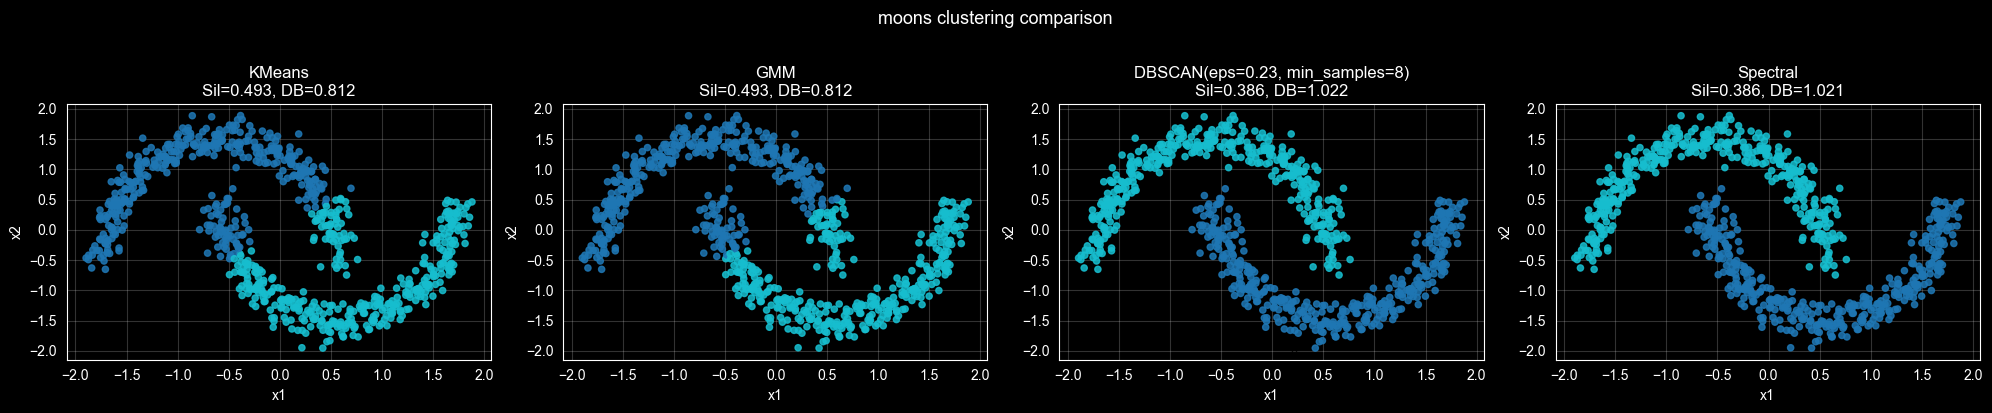

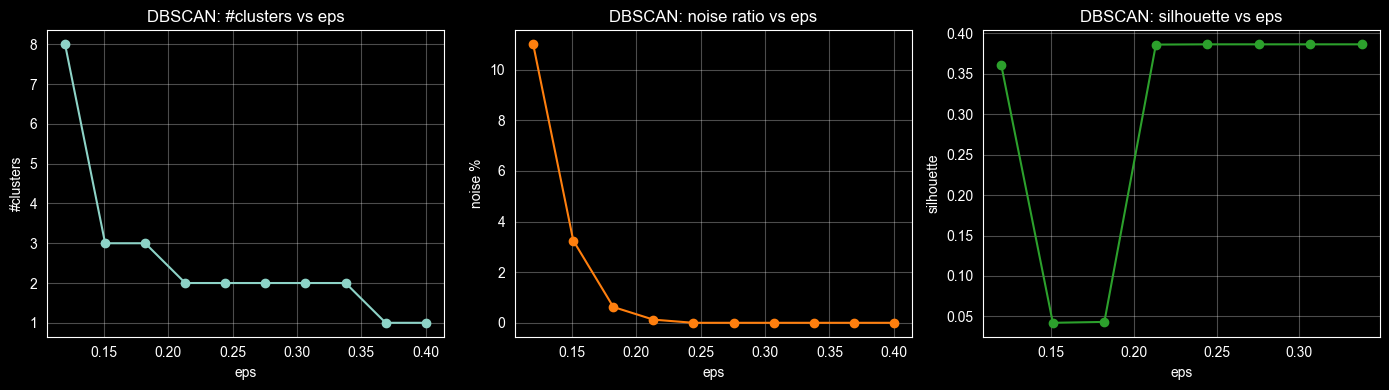

In [10]:
def main() -> None:
    # 可切换测试数据集: "moons", "blobs", "aniso_blobs"
    dataset_type = "moons"
    X = make_dataset(dataset_type=dataset_type, n_samples=800)

    # 对四种聚类方法进行比较
    results = [
        run_kmeans(X, n_clusters=2),
        run_gmm(X, n_components=2),
        run_dbscan(X, eps=0.23, min_samples=8),
        run_spectral(X, n_clusters=2),
    ]

    print_result_table(results)
    plot_clusters(X, results, title_prefix=dataset_type)

    # 进阶分析：DBSCAN 的 eps 敏感性
    eps_values = np.linspace(0.12, 0.40, 10)
    clusters, noise_ratios, silhouettes = dbscan_eps_sweep(X, eps_values, min_samples=8)
    plot_dbscan_sweep(eps_values, clusters, noise_ratios, silhouettes)


if __name__ == "__main__":
    main()